# 04 · Modelado P0 - Colab

- **Proyecto:** Detección de Residuos Urbanos · Computer Vision · UNI 2026-I
- **Autor:** Jairzinho Santos

Los modelos centrales, todos técnica del curso: transfer learning (VGG-16),
interpretabilidad (CAM / Grad-CAM / Guided Backprop), segmentación (FCN-ResNet18) y
detección (Faster R-CNN = RPN + transfer learning).

### Cómo opera esta notebook

- **Switch de hardware**: detecta Apple Silicon (MPS), Colab (CUDA) o CPU y ajusta
  device, batch, workers y rutas de datos. El mismo archivo corre en la Mac y en Colab.
- **Tolerante a fallos por experimento**: cada experimento corre dentro de un guardián;
  si uno cae, su error queda registrado en `FAILED.json` y la notebook **continúa con el
  siguiente**. Nada rompe la ejecución global.
- **Reanudable por época**: checkpoint al final de cada época. Reejecutar la notebook
  retoma cada experimento donde quedó; los terminados (`DONE.json`) se omiten.
- **Épocas honestas**: presupuesto generoso + early stopping por paciencia + curvas
  train/val — la metodología de las actividades del curso (CIFAR/CelebA).

### Los experimentos

| ID | Modelo | Datos | Presupuesto épocas | Paciencia |
|---|---|---|---|---|
| E1-E4 | VGG-16 (2 estrategias × 2 lr) | crops 224 litter/fondo | 30 | 7 |
| D1-D2 | FCN-ResNet18 (2 lr) | máscaras TACO | 80 | 15 |
| A1-A2 | Faster R-CNN (congelado vs último bloque) | taco_1cls | 50 | 10 |
| B6, B5 | Faster R-CNN (mejor estrategia de A) | taco_6cls / taco_5cls | 50 | 10 |
| C | Faster R-CNN | rolid_video_1cls | 30 | 8 |

Orden de ejecución: de barato a caro. Los análisis (CAM, anclas, objectness) usan los
modelos ya entrenados y se saltan con aviso si su experimento aún no terminó.

### Operación en tandas

`EJECUTAR = "todo"` corre todo lo pendiente. Para repartir entre la Mac y Colab, cada
instancia puede llevar una lista explícita (`["A1","A2"]`). El tablero muestra en
cualquier momento qué está DONE / RUNNING / FAILED / PENDING.

## Parte 0 · Entorno y switch de hardware

In [1]:
import sys, subprocess, importlib

def _asegurar(paquetes):
    faltan = []
    for p, m in paquetes:
        try:
            importlib.import_module(m)
        except ImportError:
            faltan.append(p)
    if faltan:
        print("instalando:", faltan)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + faltan, check=False)

_asegurar([("torch", "torch"), ("torchvision", "torchvision"),
           ("pycocotools", "pycocotools"), ("matplotlib", "matplotlib"),
           ("pandas", "pandas")])

import os, gc, json, time, math, shutil, datetime, traceback, collections, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageOps
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
from IPython.display import display

# ── Detección de entorno ─────────────────────────────────────────────────────
EN_COLAB = "google.colab" in sys.modules
if torch.cuda.is_available():
    PERFIL, DISPOSITIVO = "colab" if EN_COLAB else "cuda", torch.device("cuda")
    _gpu = torch.cuda.get_device_name(0)
    _vram = torch.cuda.get_device_properties(0).total_memory / 1e9
elif torch.backends.mps.is_available():
    PERFIL, DISPOSITIVO = "mac", torch.device("mps")
    _gpu, _vram = "Apple Silicon (MPS)", 0
else:
    PERFIL, DISPOSITIVO = "cpu", torch.device("cpu")
    _gpu, _vram = "CPU", 0

# ── Rutas ────────────────────────────────────────────────────────────────────
_cwd     = Path.cwd()
CODE_DIR = _cwd.parent if _cwd.name == "notebooks" else _cwd
GOLD     = CODE_DIR / "data" / "gold"
RUNS     = CODE_DIR / "experiments" / "p0"
FIG_DIR  = CODE_DIR / "reports" / "figuras_p0"
for d in (RUNS, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Bootstrap de datos en Colab ──────────────────────────────────────────────
RUTA_DRIVE_ZIP = "/content/drive/MyDrive/gold_colab_p0.zip"
if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # los checkpoints DEBEN vivir en Drive: /content es efímero y una
    # desconexión perdería el progreso; con Drive, la reanudación por época
    # sobrevive cualquier corte de sesión
    RUNS = Path("/content/drive/MyDrive/waste_p0_runs")
    RUNS.mkdir(parents=True, exist_ok=True)
    if not (GOLD / "pool").exists():
        print("desempaquetando gold desde Drive...")
        GOLD.mkdir(parents=True, exist_ok=True)
        import zipfile
        with zipfile.ZipFile(RUTA_DRIVE_ZIP) as z:
            z.extractall(GOLD)

# ── Configuración por perfil ─────────────────────────────────────────────────
CFG_PERFIL = {
    "mac":   {"bs_cls": 64, "bs_seg": 8,  "bs_det": 4, "workers": 8,  "ctx": "fork"},
    "colab": {"bs_cls": 128, "bs_seg": 16, "bs_det": 8, "workers": 2,  "ctx": None},
    "cuda":  {"bs_cls": 128, "bs_seg": 16, "bs_det": 8, "workers": 4,  "ctx": None},
    "cpu":   {"bs_cls": 16, "bs_seg": 2,  "bs_det": 2, "workers": 0,  "ctx": None},
}[PERFIL]
USAR_AMP = DISPOSITIVO.type == "cuda"

# ── Qué correr en esta instancia ─────────────────────────────────────────────
EJECUTAR = ["A1", "A2", "B6", "B5", "C"]          # "todo" | lista de ids, p. ej. ["E1", "E2", "D1"]
FORZAR   = []              # ids a rehacer desde cero aunque estén DONE

# ── Modo prueba: reduce datos y épocas para validar el pipeline ──────────────
PRUEBA_RAPIDA = False

SEMILLA = 42
torch.manual_seed(SEMILLA); np.random.seed(SEMILLA); random.seed(SEMILLA)

# ── Anti-suspensión en la Mac ────────────────────────────────────────────────
_caf = None
if PERFIL == "mac" and shutil.which("caffeinate"):
    _caf = subprocess.Popen(["caffeinate", "-dims"])
    print("caffeinate activo (PID {})".format(_caf.pid))

print("perfil     :", PERFIL, "·", _gpu, ("· {:.0f} GB".format(_vram) if _vram else ""))
print("torch      :", torch.__version__, "· torchvision", torchvision.__version__)
print("gold       :", GOLD)
print("runs       :", RUNS)
if PRUEBA_RAPIDA:
    print("[ MODO PRUEBA RÁPIDA ]")
assert (GOLD / "pool").exists(), "gold/pool no existe: ejecutar la notebook 03 primero"

Mounted at /content/drive
desempaquetando gold desde Drive...
perfil     : colab · NVIDIA A100-SXM4-40GB · 42 GB
torch      : 2.11.0+cu128 · torchvision 0.26.0+cu128
gold       : /content/data/gold
runs       : /content/drive/MyDrive/waste_p0_runs


## Parte 1 · Registro de experimentos

El guardián `ejecutar()` es la pieza que hace la notebook tolerante a fallos: envuelve
cada experimento, registra `DONE.json` (con métricas) o `FAILED.json` (con traceback
completo) y **nunca deja escapar una excepción** el fallo de un modelo no interrumpe a
los demás. `KeyboardInterrupt` sí se propaga: interrumpir a mano detiene la notebook,
y la reejecución retoma del último checkpoint.

In [2]:
def dir_exp(exp_id):
    d = RUNS / exp_id
    d.mkdir(parents=True, exist_ok=True)
    return d


def estado_exp(exp_id):
    d = RUNS / exp_id
    if (d / "DONE.json").exists():
        return "DONE"
    if (d / "FAILED.json").exists():
        return "FAILED"
    log = d / "log.txt"
    if log.exists() and time.time() - log.stat().st_mtime < 300:
        return "RUNNING"
    if (d / "checkpoint.pt").exists():
        return "PARCIAL"
    return "PENDING"


def registrar(exp_id, linea):
    with open(dir_exp(exp_id) / "log.txt", "a") as f:
        f.write("[{}] {}\n".format(datetime.datetime.now().isoformat(timespec="seconds"), linea))


def liberar_memoria():
    """Suelta los buffers del acelerador entre experimentos. Sin esto, los estados
    de modelos anteriores se acumulan y degradan progresivamente las corridas
    largas (medido en el modo prueba: 6x de diferencia entre experimentos)."""
    gc.collect()
    if DISPOSITIVO.type == "mps":
        try:
            torch.mps.empty_cache()
        except Exception:
            pass
    elif DISPOSITIVO.type == "cuda":
        torch.cuda.empty_cache()


def ejecutar(exp_id, fn, descripcion=""):
    """Guardián: corre fn(exp_id); DONE/FAILED según resultado; nunca rompe la notebook."""
    if EJECUTAR != "todo" and exp_id not in EJECUTAR:
        print("[omitido] {} (no está en EJECUTAR)".format(exp_id)); return
    d = dir_exp(exp_id)
    if exp_id in FORZAR:
        for f_ in ("DONE.json", "FAILED.json", "checkpoint.pt", "metrics.json"):
            (d / f_).unlink(missing_ok=True)
    if (d / "DONE.json").exists():
        print("[DONE ya] {} — se omite".format(exp_id)); return
    (d / "FAILED.json").unlink(missing_ok=True)   # reintento tras fallo
    print("\n" + "─" * 96)
    print("EXPERIMENTO {} · {}".format(exp_id, descripcion))
    print("─" * 96)
    registrar(exp_id, "inicio · perfil=" + PERFIL)
    t0 = time.time()
    try:
        metricas = fn(exp_id)
        metricas = metricas or {}
        metricas["tiempo_s"] = round(time.time() - t0, 1)
        metricas["dispositivo"] = str(DISPOSITIVO)
        (d / "DONE.json").write_text(json.dumps(
            {"exp": exp_id, "terminado": datetime.datetime.now().isoformat(timespec="seconds"),
             **metricas}, indent=2, ensure_ascii=False, default=float))
        registrar(exp_id, "DONE en {:.0f}s".format(time.time() - t0))
        print("[DONE] {} en {:.0f} min".format(exp_id, (time.time() - t0) / 60))
    except KeyboardInterrupt:
        registrar(exp_id, "interrumpido a mano — checkpoint conservado")
        print("[interrumpido] {} — el checkpoint permite reanudar".format(exp_id))
        raise
    except Exception as e:
        tb = traceback.format_exc()
        (d / "FAILED.json").write_text(json.dumps(
            {"exp": exp_id, "error": str(e)[:500], "traceback": tb,
             "cuando": datetime.datetime.now().isoformat(timespec="seconds")}, indent=2))
        registrar(exp_id, "FAILED: " + str(e)[:200])
        print("[FALLÓ] {} — {}: {}".format(exp_id, type(e).__name__, str(e)[:200]))
        print("        traceback completo en {}".format(d / "FAILED.json"))
        print("        la notebook continúa con el siguiente experimento")
    finally:
        liberar_memoria()


def cuarentena_nan():
    """Aparta los runs cuyo entrenamiento divergio (perdida no finita en el
    historial). Motivo: en la corrida real, A1 divergio a NaN y quedo registrado
    como DONE con AP 0 — un resultado invalido no debe bloquear el reintento ni
    contaminar la consolidacion. No toca experimentos en ejecucion."""
    if not RUNS.exists():
        return
    for d in sorted(RUNS.iterdir()):
        if not d.is_dir() or d.name.startswith("_cuarentena"):
            continue
        log = d / "log.txt"
        if log.exists() and time.time() - log.stat().st_mtime < 300:
            continue
        hist = None
        try:
            if (d / "DONE.json").exists():
                hist = json.loads((d / "DONE.json").read_text()).get("hist", {})
            elif (d / "checkpoint.pt").exists():
                hist = torch.load(d / "checkpoint.pt", map_location="cpu",
                                  weights_only=False).get("hist", {})
        except Exception:
            continue
        perdidas = (hist or {}).get("tr_loss", [])
        divergio = any(isinstance(v, float) and (not math.isfinite(v) or abs(v) > 1e4)
                       for v in perdidas)
        # caso real de A2: FAILED por divergencia con un checkpoint contaminado
        # a cuestas — reanudarlo repetiria el NaN al instante
        if not divergio and (d / "FAILED.json").exists() and (d / "checkpoint.pt").exists():
            try:
                err = json.loads((d / "FAILED.json").read_text()).get("error", "")
                divergio = ("no finita" in err) or ("divergio" in err)
            except Exception:
                pass
        if divergio:
            destino = RUNS / ("_cuarentena_" + d.name + "_" +
                              datetime.datetime.now().strftime("%m%d_%H%M"))
            d.rename(destino)
            print("[cuarentena] {}: entrenamiento divergido -> {}".format(
                d.name, destino.name))


cuarentena_nan()

PLAN = ["E1", "E2", "E3", "E4", "D1", "D2", "A1", "A2", "B6", "B5", "C"]


def tablero():
    filas = []
    for e in PLAN:
        est = estado_exp(e)
        extra = ""
        d = RUNS / e
        if est == "DONE":
            m = json.loads((d / "DONE.json").read_text())
            claves = [k for k in ("val_acc", "val_iou", "val_ap50") if k in m.get("mejor", {})]
            if claves:
                extra = "{}={:.3f}".format(claves[0], m["mejor"][claves[0]])
            extra += "  {:.0f} min".format(m.get("tiempo_total_s", m.get("tiempo_s", 0)) / 60)
        elif est == "FAILED":
            extra = json.loads((d / "FAILED.json").read_text())["error"][:60]
        elif est in ("PARCIAL", "RUNNING"):
            try:
                ck = torch.load(d / "checkpoint.pt", map_location="cpu", weights_only=False)
                extra = "época {}".format(ck.get("epoca", "?"))
            except Exception:
                extra = ""
        filas.append({"exp": e, "estado": est, "detalle": extra})
    display(pd.DataFrame(filas).set_index("exp"))


tablero()

,estado,detalle
exp,,
E1,PENDING,
E2,PENDING,
E3,PENDING,
E4,PENDING,
D1,PENDING,
D2,PENDING,
A1,PENDING,
A2,PENDING,
B6,PENDING,


## Parte 2 · Datos

Datasets sobre los artefactos de gold. En la Mac los workers usan contexto `fork`
(el `spawn` por defecto de macOS no puede importar funciones definidas en un notebook);
si la prueba de carga falla, se degrada a 0 workers automáticamente.

In [3]:
NORM_IMAGENET = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


class DatasetRecortes(torch.utils.data.Dataset):
    """crops/<ds>/<split>/{litter,fondo}/*.jpg -> (tensor, etiqueta, dataset_origen)."""
    def __init__(self, split, entrenar):
        self.items = []
        for ds in ("taco", "rolid11k", "uavvaste"):
            for cl, y in (("litter", 1), ("fondo", 0)):
                for p in sorted((GOLD / "crops" / ds / split / cl).glob("*.jpg")):
                    self.items.append((p, y, ds))
        if PRUEBA_RAPIDA:
            rng = random.Random(0); rng.shuffle(self.items)
            self.items = self.items[:120]
        ts = [transforms.ToTensor(), transforms.Normalize(*NORM_IMAGENET)]
        if entrenar:
            ts = [transforms.RandomHorizontalFlip()] + ts
        self.tf = transforms.Compose(ts)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        p, y, ds = self.items[i]
        return self.tf(Image.open(p).convert("RGB")), y, ds


class DatasetMascaras(torch.utils.data.Dataset):
    """pool/taco + masks/taco reescalados a tamaño fijo (estilo FCN del curso)."""
    TAM = (320, 480)   # (alto, ancho)

    def __init__(self, split):
        sp = json.loads((GOLD / "coco" / "taco_1cls_{}.json".format(split)).read_text())
        self.items = [Path(i["file_name"]).name for i in sp["images"]]
        if PRUEBA_RAPIDA:
            self.items = self.items[:16]
        self.norm = transforms.Normalize(*NORM_IMAGENET)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        n = self.items[i]
        im = Image.open(GOLD / "pool" / "taco" / n).convert("RGB")
        mk = Image.open(GOLD / "masks" / "taco" / n.replace(".jpg", ".png"))
        im = im.resize(self.TAM[::-1], Image.BILINEAR)
        mk = mk.resize(self.TAM[::-1], Image.NEAREST)
        x = self.norm(transforms.functional.to_tensor(im))
        y = torch.from_numpy((np.asarray(mk) > 0).astype(np.int64))
        return x, y


class DatasetDeteccion(torch.utils.data.Dataset):
    """gold/coco/<exp>_<split>.json -> (tensor, target torchvision)."""
    def __init__(self, exp, split):
        d = json.loads((GOLD / "coco" / "{}_{}.json".format(exp, split)).read_text())
        anns = collections.defaultdict(list)
        for a in d["annotations"]:
            anns[a["image_id"]].append(a)
        self.items = [(i, anns[i["id"]]) for i in d["images"] if anns[i["id"]]]
        if PRUEBA_RAPIDA:
            self.items = self.items[:24 if split == "train" else 8]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, k):
        info, anns = self.items[k]
        im = Image.open(GOLD / info["file_name"]).convert("RGB")
        cajas = []
        etiquetas = []
        for a in anns:
            x, y, w, h = a["bbox"]
            if w > 1 and h > 1:
                cajas.append([x, y, x + w, y + h])
                etiquetas.append(a["category_id"])
        target = {"boxes": torch.tensor(cajas, dtype=torch.float32),
                  "labels": torch.tensor(etiquetas, dtype=torch.int64),
                  "image_id": torch.tensor([info["id"]])}
        return transforms.functional.to_tensor(im), target


def _colate_det(lote):
    return tuple(zip(*lote))


def cargador(dataset, bs, entrenar, colate=None):
    kw = {}
    n_work = CFG_PERFIL["workers"] if not PRUEBA_RAPIDA else 0
    if n_work and CFG_PERFIL["ctx"]:
        kw["multiprocessing_context"] = CFG_PERFIL["ctx"]
        kw["persistent_workers"] = True
    dl = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=entrenar,
                                     num_workers=n_work, collate_fn=colate, **kw)
    try:                                  # prueba de humo: un lote
        next(iter(dl))
        return dl
    except Exception as e:
        print("  [aviso] workers={} falló ({}); degradando a 0 workers".format(
            n_work, type(e).__name__))
        return torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=entrenar,
                                           num_workers=0, collate_fn=colate)


print("recortes train:", len(DatasetRecortes("train", True)))
print("máscaras train:", len(DatasetMascaras("train")))
print("detección taco_1cls train:", len(DatasetDeteccion("taco_1cls", "train")))

recortes train: 41120
máscaras train: 987
detección taco_1cls train: 987


## Parte 3 · Bloque E - VGG-16 con transfer learning (E1-E4)

La receta de la actividad CelebA, sobre nuestros recortes: congelar la base convolucional
frente a descongelar el último bloque, con dos learning rates. `BCEWithLogitsLoss`, curvas
por época, y el test se toca una sola vez al final del mejor.

In [4]:
CFG_E = {
    "E1": {"estrategia": "congelado",    "lr": 1e-3},
    "E2": {"estrategia": "congelado",    "lr": 1e-4},
    "E3": {"estrategia": "ultimo_bloque", "lr": 1e-3},
    "E4": {"estrategia": "ultimo_bloque", "lr": 1e-4},
}
EPOCAS_E, PACIENCIA_E = (30, 7) if not PRUEBA_RAPIDA else (2, 1)


def construir_vgg(estrategia):
    m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for p in m.features.parameters():
        p.requires_grad = False
    if estrategia == "ultimo_bloque":       # bloque conv5: índices 24..30
        for p in m.features[24:].parameters():
            p.requires_grad = True
    m.classifier = nn.Sequential(
        nn.Linear(25088, 4096), nn.ReLU(True), nn.Dropout(0.5),
        nn.Linear(4096, 1024), nn.ReLU(True), nn.Dropout(0.5),
        nn.Linear(1024, 1))
    return m


def entrenar_clasificador(exp_id):
    cfg = CFG_E[exp_id]
    d = dir_exp(exp_id)
    tr = cargador(DatasetRecortes("train", True), CFG_PERFIL["bs_cls"], True)
    va = cargador(DatasetRecortes("val", False), CFG_PERFIL["bs_cls"], False)

    modelo = construir_vgg(cfg["estrategia"]).to(DISPOSITIVO)
    opt = torch.optim.Adam([p for p in modelo.parameters() if p.requires_grad], lr=cfg["lr"])
    crit = nn.BCEWithLogitsLoss()

    epoca0, hist = 0, {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": []}
    mejor, mejor_estado, paciencia = -1.0, None, 0
    ck = d / "checkpoint.pt"
    if ck.exists():
        s = torch.load(ck, map_location=DISPOSITIVO, weights_only=False)
        modelo.load_state_dict(s["modelo"]); opt.load_state_dict(s["opt"])
        epoca0, hist, mejor, paciencia = s["epoca"] + 1, s["hist"], s["mejor"], s["paciencia"]
        mejor_estado = s["mejor_estado"]
        print("  reanudando desde la época {}".format(epoca0))

    for ep in range(epoca0, EPOCAS_E):
        modelo.train(); tl = ta = n = 0
        for x, y, _ in tr:
            x, y = x.to(DISPOSITIVO), y.float().to(DISPOSITIVO)
            opt.zero_grad()
            o = modelo(x).squeeze(1)
            loss = crit(o, y); loss.backward(); opt.step()
            tl += loss.item() * len(y); ta += ((o > 0) == y.bool()).sum().item(); n += len(y)
        modelo.eval(); vl = vaa = m_ = 0
        with torch.no_grad():
            for x, y, _ in va:
                x, y = x.to(DISPOSITIVO), y.float().to(DISPOSITIVO)
                o = modelo(x).squeeze(1)
                vl += crit(o, y).item() * len(y)
                vaa += ((o > 0) == y.bool()).sum().item(); m_ += len(y)
        hist["tr_loss"].append(tl / n); hist["tr_acc"].append(ta / n)
        hist["va_loss"].append(vl / m_); hist["va_acc"].append(vaa / m_)
        if hist["va_acc"][-1] > mejor:
            mejor, paciencia = hist["va_acc"][-1], 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            paciencia += 1
        registrar(exp_id, "época {} · va_acc {:.4f} (mejor {:.4f})".format(
            ep, hist["va_acc"][-1], mejor))
        print("  época {:>2}/{} · tr_acc {:.3f} · va_acc {:.3f} · mejor {:.3f}".format(
            ep + 1, EPOCAS_E, hist["tr_acc"][-1], hist["va_acc"][-1], mejor))
        torch.save({"modelo": modelo.state_dict(), "opt": opt.state_dict(), "epoca": ep,
                    "hist": hist, "mejor": mejor, "paciencia": paciencia,
                    "mejor_estado": mejor_estado}, ck)
        if paciencia >= PACIENCIA_E:
            print("  early stopping (paciencia {})".format(PACIENCIA_E)); break

    # test una sola vez, con el mejor estado
    modelo.load_state_dict(mejor_estado); modelo.eval()
    te = cargador(DatasetRecortes("test", False), CFG_PERFIL["bs_cls"], False)
    ok = tot = 0; por_ds = collections.Counter(); tot_ds = collections.Counter()
    with torch.no_grad():
        for x, y, ds in te:
            o = modelo(x.to(DISPOSITIVO)).squeeze(1).cpu()
            corr = ((o > 0) == y.bool())
            ok += corr.sum().item(); tot += len(y)
            for c, d_ in zip(corr.tolist(), ds):
                por_ds[d_] += c; tot_ds[d_] += 1
    torch.save(mejor_estado, d / "mejor.pt")
    return {"config": cfg, "hist": hist, "epocas_efectivas": len(hist["va_acc"]),
            "mejor": {"val_acc": mejor},
            "test": {"acc": ok / max(tot, 1),
                     "acc_por_dataset": {k: por_ds[k] / tot_ds[k] for k in tot_ds}}}


for _e in ("E1", "E2", "E3", "E4"):
    ejecutar(_e, entrenar_clasificador,
             "VGG-16 {} lr={}".format(CFG_E[_e]["estrategia"], CFG_E[_e]["lr"]))

[omitido] E1 (no está en EJECUTAR)
[omitido] E2 (no está en EJECUTAR)
[omitido] E3 (no está en EJECUTAR)
[omitido] E4 (no está en EJECUTAR)


In [5]:
# ── Curvas del bloque E ──────────────────────────────────────────────────────
hechos = [e for e in ("E1", "E2", "E3", "E4") if estado_exp(e) == "DONE"]
if hechos:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    for e in hechos:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        h = m["hist"]
        lab = "{} ({}, lr={})".format(e, m["config"]["estrategia"], m["config"]["lr"])
        axes[0].plot(h["va_loss"], label=lab)
        axes[1].plot(h["va_acc"], label=lab)
    axes[0].set_title("Pérdida de validación", loc="left"); axes[0].set_xlabel("época")
    axes[1].set_title("Accuracy de validación", loc="left"); axes[1].set_xlabel("época")
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    fig.tight_layout(); fig.savefig(FIG_DIR / "E_curvas.png", bbox_inches="tight")
    display(fig); plt.close(fig)

    filas = []
    for e in hechos:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        filas.append({"exp": e, **m["config"], "val_acc": m["mejor"]["val_acc"],
                      "test_acc": m["test"]["acc"],
                      **{"test_" + k: v for k, v in m["test"]["acc_por_dataset"].items()}})
    display(pd.DataFrame(filas).set_index("exp").round(4))
else:
    print("ningún experimento E terminado aún")

ningún experimento E terminado aún


## Parte 4 · Interpretabilidad - CAM, Grad-CAM y Guided Backprop

Sobre el mejor clasificador del bloque E, con la mecánica de las notebooks del curso:
hooks para Grad-CAM y ReLU guiada para el backprop. Mapas sobre recortes de test de los
tres dominios.

In [6]:
_hechos = [e for e in ("E1", "E2", "E3", "E4") if estado_exp(e) == "DONE"]
if not _hechos:
    print("[omitido] requiere al menos un experimento E terminado")
else:
    _mejor_e = max(_hechos, key=lambda e: json.loads(
        (RUNS / e / "DONE.json").read_text())["mejor"]["val_acc"])
    print("usando", _mejor_e)
    _cfg = json.loads((RUNS / _mejor_e / "DONE.json").read_text())["config"]
    modelo_cam = construir_vgg(_cfg["estrategia"])
    modelo_cam.load_state_dict(torch.load(RUNS / _mejor_e / "mejor.pt",
                                          map_location="cpu", weights_only=False))
    modelo_cam = modelo_cam.to(DISPOSITIVO).eval()
    # las ReLU inplace de VGG rompen los full_backward_hooks: se desactivan
    for _m in modelo_cam.modules():
        if isinstance(_m, nn.ReLU):
            _m.inplace = False

    # ── Grad-CAM con hooks (estilo curso) ────────────────────────────────────
    _act, _grad = {}, {}
    _capa = modelo_cam.features[28]           # última convolución de VGG-16
    _h1 = _capa.register_forward_hook(lambda m, i, o: _act.update(v=o.detach()))
    _h2 = _capa.register_full_backward_hook(lambda m, gi, go: _grad.update(v=go[0].detach()))

    def gradcam(x):
        # el gradiente entra por la ENTRADA: con el backbone congelado los
        # parámetros no requieren grad y sin esto el hook jamás dispararía
        xg = x.clone().unsqueeze(0).to(DISPOSITIVO).requires_grad_(True)
        modelo_cam.zero_grad()
        sal = modelo_cam(xg).squeeze()
        sal.backward()
        A, G = _act["v"][0], _grad["v"][0]
        pesos = G.mean(dim=(1, 2), keepdim=True)
        cam = F.relu((pesos * A).sum(0)).cpu().numpy()
        cam = cam / (cam.max() + 1e-8)
        return float(torch.sigmoid(sal)), cam

    # ── Guided Backprop: ReLU que solo deja pasar gradiente positivo ─────────
    _hooks_gb = []
    def _activar_gb():
        for m in modelo_cam.modules():
            if isinstance(m, nn.ReLU):
                _hooks_gb.append(m.register_full_backward_hook(
                    lambda mod, gi, go: (torch.clamp(gi[0], min=0.0),)))
    def _desactivar_gb():
        for h in _hooks_gb:
            h.remove()
        _hooks_gb.clear()

    def guided(x):
        xg = x.clone().unsqueeze(0).to(DISPOSITIVO).requires_grad_(True)
        _activar_gb()
        try:
            modelo_cam.zero_grad()
            modelo_cam(xg).squeeze().backward()
            g = xg.grad[0].detach().cpu().numpy().transpose(1, 2, 0)
        finally:
            _desactivar_gb()
        g = np.abs(g).sum(2)
        return g / (g.max() + 1e-8)

    # ── Panel por dataset ────────────────────────────────────────────────────
    def _desnorm(x):
        m, s = torch.tensor(NORM_IMAGENET[0]), torch.tensor(NORM_IMAGENET[1])
        return (x * s[:, None, None] + m[:, None, None]).clamp(0, 1).numpy().transpose(1, 2, 0)

    te = DatasetRecortes("test", False)
    rng = random.Random(5)
    idx_litter = [i for i, (p, y, ds) in enumerate(te.items) if y == 1]
    rng.shuffle(idx_litter)
    por_ds = collections.defaultdict(list)
    for i in idx_litter:
        ds = te.items[i][2]
        if len(por_ds[ds]) < 3:
            por_ds[ds].append(i)

    fig, axes = plt.subplots(len(por_ds) * 3, 4, figsize=(11, 2.6 * len(por_ds) * 3))
    fila = 0
    for ds, idxs in por_ds.items():
        for i in idxs:
            x, y, _ = te[i]
            prob, cam = gradcam(x)
            gb = guided(x)
            img = _desnorm(x)
            cam_r = np.array(Image.fromarray((cam * 255).astype(np.uint8))
                             .resize((224, 224), Image.BILINEAR)) / 255.0
            for j, (tit, contenido) in enumerate([
                    ("{} · p={:.2f}".format(ds, prob), img),
                    ("Grad-CAM", None), ("Guided BP", gb), ("Guided x CAM", gb * cam_r)]):
                ax = axes[fila, j]
                if j == 1:
                    ax.imshow(img); ax.imshow(cam_r, cmap="jet", alpha=0.45)
                elif j == 0:
                    ax.imshow(contenido)
                else:
                    ax.imshow(contenido, cmap="gray")
                ax.set_title(tit, fontsize=8); ax.axis("off")
            fila += 1
    fig.tight_layout(); fig.savefig(FIG_DIR / "CAM_panel.png", bbox_inches="tight", dpi=150)
    display(fig); plt.close(fig)
    _h1.remove(); _h2.remove()
    del modelo_cam
    liberar_memoria()

[omitido] requiere al menos un experimento E terminado


## Parte 5 · Bloque D - FCN-ResNet18 (D1–D2)

La arquitectura de la notebook del curso al pie de la letra: ResNet-18 sin las dos últimas
capas + conv 1×1 a 2 clases + conv transpuesta ×32 con inicialización bilineal. Pérdida CE
con peso de clase (litter cubre ~2.5 % de los píxeles). Métrica: IoU de la clase litter.

In [7]:
CFG_D = {"D1": {"lr": 1e-3}, "D2": {"lr": 1e-4}}
EPOCAS_D, PACIENCIA_D = (80, 15) if not PRUEBA_RAPIDA else (2, 1)


def _peso_bilineal(canales, k):
    factor = (k + 1) // 2
    centro = factor - 1 if k % 2 == 1 else factor - 0.5
    og = (torch.arange(k).reshape(-1, 1), torch.arange(k).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - centro) / factor) * (1 - torch.abs(og[1] - centro) / factor)
    w = torch.zeros((canales, canales, k, k))
    w[range(canales), range(canales)] = filt
    return w


def construir_fcn():
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    fcn = nn.Sequential(*list(base.children())[:-2])
    fcn.add_module("conv_final", nn.Conv2d(512, 2, kernel_size=1))
    fcn.add_module("transpuesta", nn.ConvTranspose2d(2, 2, kernel_size=64,
                                                     padding=16, stride=32))
    fcn.transpuesta.weight.data.copy_(_peso_bilineal(2, 64))
    return fcn


def entrenar_fcn(exp_id):
    cfg = CFG_D[exp_id]
    d = dir_exp(exp_id)
    tr = cargador(DatasetMascaras("train"), CFG_PERFIL["bs_seg"], True)
    va = cargador(DatasetMascaras("val"), CFG_PERFIL["bs_seg"], False)

    modelo = construir_fcn().to(DISPOSITIVO)
    peso = torch.tensor([1.0, 12.0], device=DISPOSITIVO)   # litter ~2.5% de píxeles
    crit = nn.CrossEntropyLoss(weight=peso)
    opt = torch.optim.SGD(modelo.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=1e-3)

    epoca0, hist = 0, {"tr_loss": [], "va_loss": [], "va_iou": []}
    mejor, mejor_estado, paciencia = -1.0, None, 0
    ck = d / "checkpoint.pt"
    if ck.exists():
        s = torch.load(ck, map_location=DISPOSITIVO, weights_only=False)
        modelo.load_state_dict(s["modelo"]); opt.load_state_dict(s["opt"])
        epoca0, hist, mejor, paciencia = s["epoca"] + 1, s["hist"], s["mejor"], s["paciencia"]
        mejor_estado = s["mejor_estado"]
        print("  reanudando desde la época {}".format(epoca0))

    def _eval(dl):
        modelo.eval(); vl = inter = union = px = 0
        with torch.no_grad():
            for x, y in dl:
                x, y = x.to(DISPOSITIVO), y.to(DISPOSITIVO)
                o = modelo(x)
                vl += crit(o, y).item() * len(x)
                pred = o.argmax(1)
                inter += ((pred == 1) & (y == 1)).sum().item()
                union += ((pred == 1) | (y == 1)).sum().item()
                px += len(x)
        return vl / px, inter / max(union, 1)

    for ep in range(epoca0, EPOCAS_D):
        modelo.train(); tl = n = 0
        for x, y in tr:
            x, y = x.to(DISPOSITIVO), y.to(DISPOSITIVO)
            opt.zero_grad()
            loss = crit(modelo(x), y); loss.backward(); opt.step()
            tl += loss.item() * len(x); n += len(x)
        vl, viou = _eval(va)
        hist["tr_loss"].append(tl / n); hist["va_loss"].append(vl); hist["va_iou"].append(viou)
        if viou > mejor:
            mejor, paciencia = viou, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            paciencia += 1
        registrar(exp_id, "época {} · va_iou {:.4f} (mejor {:.4f})".format(ep, viou, mejor))
        print("  época {:>2}/{} · tr_loss {:.3f} · va_iou {:.3f} · mejor {:.3f}".format(
            ep + 1, EPOCAS_D, hist["tr_loss"][-1], viou, mejor))
        torch.save({"modelo": modelo.state_dict(), "opt": opt.state_dict(), "epoca": ep,
                    "hist": hist, "mejor": mejor, "paciencia": paciencia,
                    "mejor_estado": mejor_estado}, ck)
        if paciencia >= PACIENCIA_D:
            print("  early stopping"); break

    modelo.load_state_dict(mejor_estado)
    te_loss, te_iou = _eval(cargador(DatasetMascaras("test"), CFG_PERFIL["bs_seg"], False))
    torch.save(mejor_estado, d / "mejor.pt")
    return {"config": cfg, "hist": hist, "epocas_efectivas": len(hist["va_iou"]),
            "mejor": {"val_iou": mejor}, "test": {"iou_litter": te_iou, "loss": te_loss}}


for _e in ("D1", "D2"):
    ejecutar(_e, entrenar_fcn, "FCN-ResNet18 lr={}".format(CFG_D[_e]["lr"]))

[omitido] D1 (no está en EJECUTAR)
[omitido] D2 (no está en EJECUTAR)


In [8]:
# ── Predicciones FCN de ejemplo ──────────────────────────────────────────────
_hd = [e for e in ("D1", "D2") if estado_exp(e) == "DONE"]
if _hd:
    _mejor_d = max(_hd, key=lambda e: json.loads(
        (RUNS / e / "DONE.json").read_text())["mejor"]["val_iou"])
    modelo_f = construir_fcn()
    modelo_f.load_state_dict(torch.load(RUNS / _mejor_d / "mejor.pt",
                                        map_location="cpu", weights_only=False))
    modelo_f = modelo_f.to(DISPOSITIVO).eval()
    te = DatasetMascaras("test")
    rng = random.Random(11)
    fig, axes = plt.subplots(3, 3, figsize=(12, 7.5))
    for fila, i in enumerate(rng.sample(range(len(te)), min(3, len(te)))):
        x, y = te[i]
        with torch.no_grad():
            pred = modelo_f(x.unsqueeze(0).to(DISPOSITIVO)).argmax(1)[0].cpu().numpy()
        m_, s_ = np.array(NORM_IMAGENET[0]), np.array(NORM_IMAGENET[1])
        img = (x.numpy().transpose(1, 2, 0) * s_ + m_).clip(0, 1)
        for j, (tit, cont, cm) in enumerate([("imagen", img, None),
                                             ("máscara real", y.numpy(), "gray"),
                                             ("predicción " + _mejor_d, pred, "gray")]):
            axes[fila, j].imshow(cont, cmap=cm)
            axes[fila, j].set_title(tit, fontsize=9); axes[fila, j].axis("off")
    fig.tight_layout(); fig.savefig(FIG_DIR / "D_predicciones.png", bbox_inches="tight", dpi=150)
    display(fig); plt.close(fig)
    for e in _hd:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        print("{}: val_iou {:.4f} · test_iou {:.4f}".format(
            e, m["mejor"]["val_iou"], m["test"]["iou_litter"]))
    del modelo_f
    liberar_memoria()
else:
    print("ningún experimento D terminado aún")

ningún experimento D terminado aún


## Parte 6 · Bloques A, B y C - Faster R-CNN

Faster R-CNN ResNet-50-FPN preentrenado en COCO (torchvision): el RPN de la notebook del
curso a escala real, con las dos estrategias de fine-tuning de la actividad CelebA.

- **A1**: backbone congelado (entrena FPN + RPN + cabezas)
- **A2**: además descongela `layer4` del backbone
- **B6 / B5**: la mejor estrategia de A sobre las variantes de 6 y 5 clases
- **C**: rolid_video (split honesto) el experimento largo

Evaluación por época sobre val con pycocotools (AP50); test una sola vez con el mejor
estado. Las predicciones de test se guardan para el análisis TIDE (notebook 06).

**Receta corregida tras la primera corrida real** (A1 divergió a NaN y A2 resultó
inviable en MPS): warmup lineal en la primera época + gradient clipping + lr 0.001,
**guardián de NaN** (pérdida no finita → FAILED inmediato con motivo) y **guardián de
velocidad** (iteración > 20 s en MPS → FAILED con instrucción de moverlo a Colab).

**Reparto recomendado de carriles**, medido en la corrida real (~0.55 s/iter la
estrategia congelada en MPS; ~128 s/iter la descongelada):

| Carril | `EJECUTAR` | Motivo |
|---|---|---|
| Mac (MPS) | `["A1", "B6", "B5"]` | estrategia congelada: ~140 s/época en TACO |
| Colab (CUDA) | `["A2", "C"]` | A2 exige backward por el backbone; C paga la evaluación de 1.991 imágenes de val por época |

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import contextlib, io as _io

EPOCAS_DET = {"A1": 50, "A2": 50, "B6": 50, "B5": 50, "C": 30}
PACIEN_DET = {"A1": 10, "A2": 10, "B6": 10, "B5": 10, "C": 8}
CFG_DET = {
    "A1": {"exp_gold": "taco_1cls", "clases": 1, "estrategia": "congelado"},
    "A2": {"exp_gold": "taco_1cls", "clases": 1, "estrategia": "layer4"},
    "B6": {"exp_gold": "taco_6cls", "clases": 6, "estrategia": None},   # se decide con A
    "B5": {"exp_gold": "taco_5cls", "clases": 5, "estrategia": None},
    "C":  {"exp_gold": "rolid_video_1cls", "clases": 1, "estrategia": None},
}
if PRUEBA_RAPIDA:
    EPOCAS_DET = {k: 2 for k in EPOCAS_DET}
    PACIEN_DET = {k: 1 for k in PACIEN_DET}

LR_DET        = 0.001
CLIP_GRAD     = 10.0

PRESUPUESTO_HORAS_EXP = 20.0  
_ITERS_MEDICION = 8          


def mejor_estrategia_A():
    """Devuelve la estrategia ganadora entre A1/A2 por val AP50; layer4 por defecto."""
    resultados = {}
    for e in ("A1", "A2"):
        if estado_exp(e) == "DONE":
            m = json.loads((RUNS / e / "DONE.json").read_text())
            resultados[m["config"]["estrategia"]] = m["mejor"]["val_ap50"]
    if not resultados:
        return "layer4"
    return max(resultados, key=resultados.get)


def construir_frcnn(n_clases, estrategia):
    m = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT,
        min_size=640, max_size=1280)
    in_f = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_f, n_clases + 1)
    for p in m.backbone.body.parameters():
        p.requires_grad = False
    if estrategia == "layer4":
        for p in m.backbone.body.layer4.parameters():
            p.requires_grad = True
    return m


def evaluar_det(modelo, exp_gold, split, guardar_en=None):
    """AP con pycocotools sobre el GT de gold. Devuelve dict de métricas."""
    gt = COCO(str(GOLD / "coco" / "{}_{}.json".format(exp_gold, split)))
    ds = DatasetDeteccion(exp_gold, split)
    dl = cargador(ds, CFG_PERFIL["bs_det"], False, colate=_colate_det)
    modelo.eval()
    preds = []
    with torch.no_grad():
        for xs, ts in dl:
            salidas = modelo([x.to(DISPOSITIVO) for x in xs])
            for t, s in zip(ts, salidas):
                iid = int(t["image_id"])
                for caja, punt, lab in zip(s["boxes"].cpu(), s["scores"].cpu(), s["labels"].cpu()):
                    x1, y1, x2, y2 = caja.tolist()
                    preds.append({"image_id": iid, "category_id": int(lab),
                                  "bbox": [x1, y1, x2 - x1, y2 - y1],
                                  "score": float(punt)})
    if not preds:
        return {"ap50": 0.0, "ap": 0.0, "ap_s": 0.0, "ap_m": 0.0, "ap_l": 0.0}
    if guardar_en:
        Path(guardar_en).write_text(json.dumps(preds))
    with contextlib.redirect_stdout(_io.StringIO()):
        dt = gt.loadRes(preds)
        ev = COCOeval(gt, dt, "bbox")
        ev.evaluate(); ev.accumulate(); ev.summarize()
    s = ev.stats
    return {"ap50": float(s[1]), "ap": float(s[0]),
            "ap_s": float(s[3]), "ap_m": float(s[4]), "ap_l": float(s[5])}


def entrenar_frcnn(exp_id):
    cfg = dict(CFG_DET[exp_id])
    if cfg["estrategia"] is None:
        cfg["estrategia"] = mejor_estrategia_A()
        print("  estrategia heredada de A:", cfg["estrategia"])
    d = dir_exp(exp_id)
    tr = cargador(DatasetDeteccion(cfg["exp_gold"], "train"), CFG_PERFIL["bs_det"],
                  True, colate=_colate_det)

    modelo = construir_frcnn(cfg["clases"], cfg["estrategia"]).to(DISPOSITIVO)
    params = [p for p in modelo.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=LR_DET, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(EPOCAS_DET[exp_id] // 3, 1),
                                            gamma=0.1)
    calentamiento = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.05, total_iters=max(len(tr), 1))

    epoca0, hist = 0, {"tr_loss": [], "va_ap50": []}
    mejor, mejor_estado, paciencia = -1.0, None, 0
    tiempo_prev, t_ini_sesion = 0.0, time.time()
    ck = d / "checkpoint.pt"
    if ck.exists():
        s = torch.load(ck, map_location=DISPOSITIVO, weights_only=False)
        modelo.load_state_dict(s["modelo"]); opt.load_state_dict(s["opt"])
        sched.load_state_dict(s["sched"])
        epoca0, hist, mejor, paciencia = s["epoca"] + 1, s["hist"], s["mejor"], s["paciencia"]
        mejor_estado = s["mejor_estado"]
        tiempo_prev = s.get("tiempo_prev_s", 0.0)
        print("  reanudando desde la época {} ({:.0f} min acumulados)".format(
            epoca0, tiempo_prev / 60))

    _medidas = []
    for ep in range(epoca0, EPOCAS_DET[exp_id]):
        modelo.train(); tl = n = 0
        t_ep = time.time()
        for xs, ts in tr:
            t_it = time.time()
            xs = [x.to(DISPOSITIVO) for x in xs]
            ts = [{k: v.to(DISPOSITIVO) for k, v in t.items()} for t in ts]
            perdidas = modelo(xs, ts)
            loss = sum(perdidas.values())
            if not math.isfinite(float(loss)):
                raise RuntimeError(
                    "perdida no finita en epoca {} iteracion {}: el entrenamiento "
                    "divergio; el run queda FAILED y en el proximo arranque la "
                    "cuarentena lo aparta".format(ep, n + 1))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, CLIP_GRAD)
            opt.step()
            if ep == 0:
                calentamiento.step()
            tl += loss.item(); n += 1
            if ep == epoca0 and 3 <= n <= _ITERS_MEDICION:
                _medidas.append(time.time() - t_it)
                if n == _ITERS_MEDICION and PRESUPUESTO_HORAS_EXP and len(_medidas) >= 3:
                    s_iter = sorted(_medidas)[len(_medidas) // 2]
                    horas = (s_iter * len(tr) * EPOCAS_DET[exp_id]) / 3600.0
                    print("  proyección: {:.1f} s/iter -> ~{:.1f} h de entrenamiento "
                          "para {} épocas (sin contar eval de val; presupuesto {:.0f} h)".format(
                              s_iter, horas, EPOCAS_DET[exp_id], PRESUPUESTO_HORAS_EXP))
                    registrar(exp_id, "proyeccion {:.1f} h ({:.2f} s/iter)".format(horas, s_iter))
                    if horas > PRESUPUESTO_HORAS_EXP:
                        raise RuntimeError(
                            "proyección de ~{:.0f} h supera el presupuesto de {:.0f} h en "
                            "{}: mover este experimento al carril Colab (CUDA)".format(
                                horas, PRESUPUESTO_HORAS_EXP, DISPOSITIVO.type))
        sched.step()
        va = evaluar_det(modelo, cfg["exp_gold"], "val")
        hist["tr_loss"].append(tl / max(n, 1)); hist["va_ap50"].append(va["ap50"])
        if va["ap50"] > mejor:
            mejor, paciencia = va["ap50"], 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            paciencia += 1
        registrar(exp_id, "época {} · va_ap50 {:.4f} (mejor {:.4f}) · {:.0f}s".format(
            ep, va["ap50"], mejor, time.time() - t_ep))
        print("  época {:>2}/{} · loss {:.3f} · va_AP50 {:.3f} · mejor {:.3f} · {:.0f}s".format(
            ep + 1, EPOCAS_DET[exp_id], hist["tr_loss"][-1], va["ap50"], mejor,
            time.time() - t_ep))
        torch.save({"modelo": modelo.state_dict(), "opt": opt.state_dict(),
                    "sched": sched.state_dict(), "epoca": ep, "hist": hist,
                    "mejor": mejor, "paciencia": paciencia, "mejor_estado": mejor_estado,
                    "tiempo_prev_s": tiempo_prev + (time.time() - t_ini_sesion)}, ck)
        if paciencia >= PACIEN_DET[exp_id]:
            print("  early stopping"); break

    modelo.load_state_dict(mejor_estado)
    test = evaluar_det(modelo, cfg["exp_gold"], "test",
                       guardar_en=d / "predicciones_test.json")
    torch.save(mejor_estado, d / "mejor.pt")
    return {"config": cfg, "hist": hist, "epocas_efectivas": len(hist["va_ap50"]),
            "mejor": {"val_ap50": mejor}, "test": test,
            "tiempo_total_s": tiempo_prev + (time.time() - t_ini_sesion)}


for _e in ("A1", "A2", "B6", "B5", "C"):
    ejecutar(_e, entrenar_frcnn, "Faster R-CNN · {}".format(CFG_DET[_e]["exp_gold"]))


────────────────────────────────────────────────────────────────────────────────────────────────
EXPERIMENTO A1 · Faster R-CNN · taco_1cls
────────────────────────────────────────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 240MB/s]
/tmp/ipykernel_2695/108062098.py:131: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  if not math.isfinite(float(loss)):


  proyección: 0.3 s/iter -> ~0.6 h de entrenamiento para 50 épocas (sin contar eval de val; presupuesto 20 h)
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  1/50 · loss 0.749 · va_AP50 0.400 · mejor 0.400 · 47s
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  2/50 · loss 0.422 · va_AP50 0.455 · mejor 0.455 · 44s
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  3/50 · loss 0.385 · va_AP50 0.473 · mejor 0.473 · 44s
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  4/50 · loss 0.371 · va_AP50 0.487 · mejor 0.487 · 45s
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  5/50 · loss 0.363 · va_AP50 0.493 · mejor 0.493 · 44s
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  época  6/50 · loss 0.354 · va_AP50 0.499 · mejor 0.499 · 44s
loading annota

,datos,estrategia,épocas,val_AP50,test_ap50,test_ap,test_ap_s,test_ap_m,test_ap_l
exp,,,,,,,,,
A1,taco_1cls,congelado,26,0.5329,0.4460,0.3006,0.0585,0.3475,0.5278
A2,taco_1cls,layer4,18,0.5420,0.4826,0.3231,0.0729,0.3637,0.5660
B6,taco_6cls,layer4,25,0.2490,0.2457,0.1536,0.0286,0.1033,0.2521
B5,taco_5cls,layer4,23,0.2828,0.2441,0.1555,0.0245,0.1117,0.2533
C,rolid_video_1cls,layer4,14,0.7079,0.7075,0.2767,0.2812,0.2339,0.0493


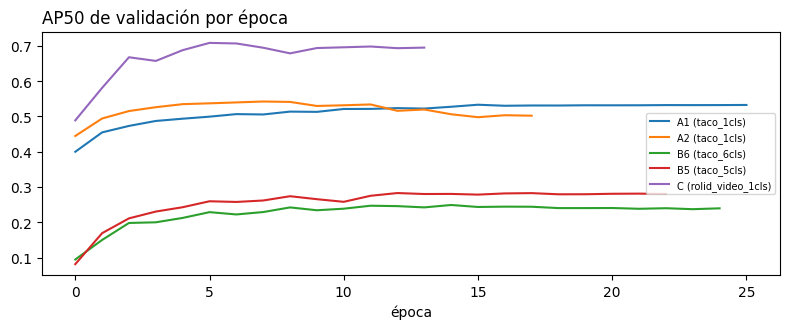

In [10]:
# ── Resumen del bloque de detección ──────────────────────────────────────────
_hdet = [e for e in ("A1", "A2", "B6", "B5", "C") if estado_exp(e) == "DONE"]
if _hdet:
    filas = []
    for e in _hdet:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        filas.append({"exp": e, "datos": m["config"]["exp_gold"],
                      "estrategia": m["config"]["estrategia"],
                      "épocas": m["epocas_efectivas"],
                      "val_AP50": m["mejor"]["val_ap50"], **{
                          "test_" + k: v for k, v in m["test"].items()}})
    display(pd.DataFrame(filas).set_index("exp").round(4))

    fig, ax = plt.subplots(figsize=(8, 3.4))
    for e in _hdet:
        m = json.loads((RUNS / e / "DONE.json").read_text())
        ax.plot(m["hist"]["va_ap50"], label="{} ({})".format(e, m["config"]["exp_gold"]))
    ax.set_title("AP50 de validación por época", loc="left")
    ax.set_xlabel("época"); ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(FIG_DIR / "det_curvas.png", bbox_inches="tight")
    display(fig); plt.close(fig)
else:
    print("ningún experimento de detección terminado aún")

## Parte 7 · Análisis de anclas y objectness

1. **Anclas contra escala de objeto**: las anclas base de la FPN de Faster R-CNN
   (32-512 px) contra la distribución real de tamaños por dataset. El objeto mediano de
   RoLID queda por debajo del ancla mínima la explicación mecanística del gap.
2. **Mapas de objectness**: la salida del RPN entrenado (C) sobre imágenes de test de
   RoLID dónde propone el detector antes de clasificar.

ANCLAS DE LA FPN CONTRA TAMAÑO REAL DE OBJETO
  taco_1cls          lado mediano  64.9px · bajo el ancla mínima (32px): 32.1%
  rolid_video_1cls   lado mediano  14.0px · bajo el ancla mínima (32px): 96.6%
  uav_1cls           lado mediano  24.9px · bajo el ancla mínima (32px): 68.7%


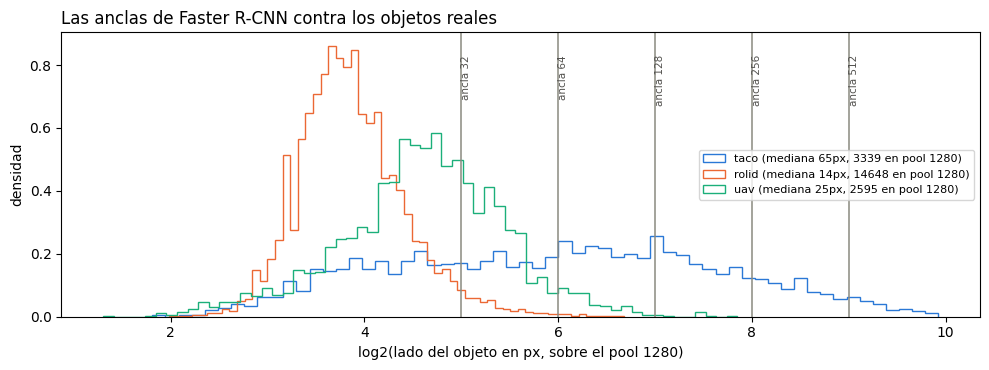

In [11]:
titulo_txt = "ANCLAS DE LA FPN CONTRA TAMAÑO REAL DE OBJETO"
print(titulo_txt)
ANCLAS = [32, 64, 128, 256, 512]
fig, ax = plt.subplots(figsize=(10, 3.8))
colores = {"taco_1cls": "#2a78d6", "rolid_video_1cls": "#eb6834", "uav_1cls": "#1baf7a"}
for exp_gold, color in colores.items():
    gt = json.loads((GOLD / "coco" / "{}_train.json".format(exp_gold)).read_text())
    lados = np.sqrt([a["bbox"][2] * a["bbox"][3] for a in gt["annotations"]
                     if a["bbox"][2] > 0])
    ax.hist(np.log2(lados), bins=60, histtype="step", lw=2, density=True,
            label="{} (mediana {:.0f}px, {} en pool 1280)".format(
                exp_gold.split("_")[0], np.median(lados), len(lados)), color=color)
    pct_bajo = (lados < ANCLAS[0]).mean() * 100
    print("  {:<18} lado mediano {:>5.1f}px · bajo el ancla mínima (32px): {:.1f}%".format(
        exp_gold, float(np.median(lados)), pct_bajo))
for a in ANCLAS:
    ax.axvline(np.log2(a), color="#8a8a80", lw=1.1)
    ax.annotate("ancla {}".format(a), xy=(np.log2(a), ax.get_ylim()[1] * 0.92),
                fontsize=7.5, rotation=90, va="top", color="#52514e")
ax.set_xlabel("log2(lado del objeto en px, sobre el pool 1280)")
ax.set_ylabel("densidad")
ax.set_title("Las anclas de Faster R-CNN contra los objetos reales", loc="left")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "anclas_vs_objetos.png", bbox_inches="tight")
display(fig); plt.close(fig)

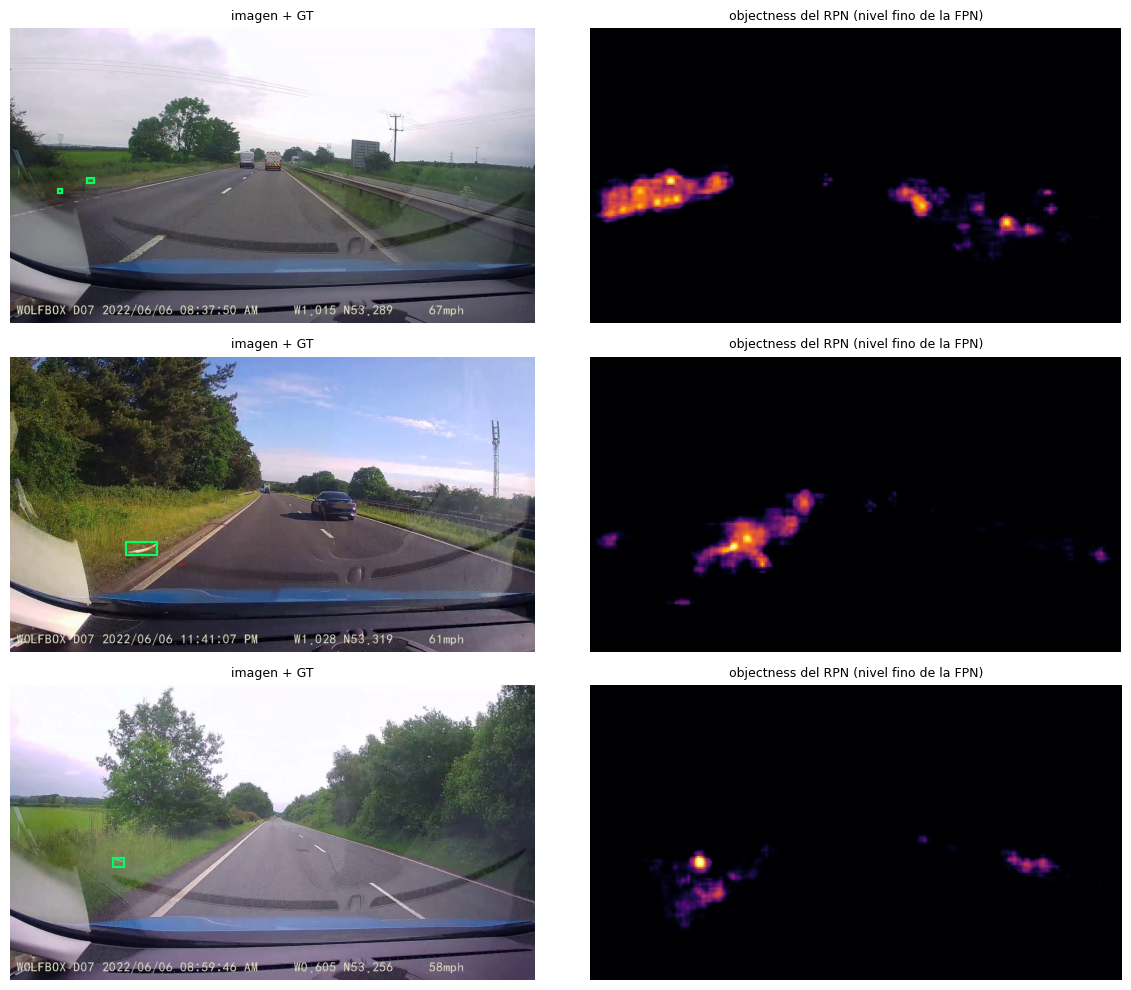

In [12]:
# ── Objectness del RPN entrenado (requiere C) ────────────────────────────────
if estado_exp("C") != "DONE":
    print("[omitido] los mapas de objectness requieren el experimento C terminado")
else:
    cfgC = json.loads((RUNS / "C" / "DONE.json").read_text())["config"]
    mod = construir_frcnn(cfgC["clases"], cfgC["estrategia"])
    mod.load_state_dict(torch.load(RUNS / "C" / "mejor.pt", map_location="cpu",
                                   weights_only=False))
    mod = mod.to(DISPOSITIVO).eval()

    ds = DatasetDeteccion("rolid_video_1cls", "test")
    rng = random.Random(21)
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    for fila, i in enumerate(rng.sample(range(len(ds)), 3)):
        x, t = ds[i]
        with torch.no_grad():
            im_list, _ = mod.transform([x.to(DISPOSITIVO)])
            feats = mod.backbone(im_list.tensors)
            objectness, _ = mod.rpn.head(list(feats.values()))
            # nivel más fino de la FPN, promediado sobre las anclas
            heat = torch.sigmoid(objectness[0][0]).mean(0).cpu().numpy()
        axes[fila, 0].imshow(x.permute(1, 2, 0))
        for caja in t["boxes"]:
            x1, y1, x2, y2 = caja.tolist()
            axes[fila, 0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                  fill=False, color="#00FF66", lw=1.6))
        axes[fila, 0].set_title("imagen + GT", fontsize=9); axes[fila, 0].axis("off")
        axes[fila, 1].imshow(heat, cmap="inferno")
        axes[fila, 1].set_title("objectness del RPN (nivel fino de la FPN)", fontsize=9)
        axes[fila, 1].axis("off")
    fig.tight_layout(); fig.savefig(FIG_DIR / "objectness_rolid.png",
                                    bbox_inches="tight", dpi=150)
    display(fig); plt.close(fig)
    del mod
    liberar_memoria()

## Parte 8 · Consolidación

In [13]:
print("═" * 96)
print("CONSOLIDACIÓN P0")
print("═" * 96)
tablero()

consolidado = {}
for e in PLAN:
    if estado_exp(e) == "DONE":
        m = json.loads((RUNS / e / "DONE.json").read_text())
        consolidado[e] = {"config": m.get("config", {}), "mejor": m.get("mejor", {}),
                          "test": m.get("test", {}),
                          "epocas_efectivas": m.get("epocas_efectivas"),
                          "tiempo_min": round(m.get("tiempo_s", 0) / 60, 1)}
(RUNS / "consolidado_p0.json").write_text(
    json.dumps({"generado": datetime.datetime.now().isoformat(timespec="seconds"),
                "perfil": PERFIL, "experimentos": consolidado},
               indent=2, ensure_ascii=False, default=float))
print("\nresumen -> {}".format(RUNS / "consolidado_p0.json"))
print("terminados: {}/{} · fallidos: {} · pendientes: {}".format(
    sum(1 for e in PLAN if estado_exp(e) == "DONE"), len(PLAN),
    [e for e in PLAN if estado_exp(e) == "FAILED"] or "ninguno",
    [e for e in PLAN if estado_exp(e) in ("PENDING", "PARCIAL")] or "ninguno"))

if _caf and _caf.poll() is None:
    _caf.terminate()
    print("caffeinate detenido")

════════════════════════════════════════════════════════════════════════════════════════════════
CONSOLIDACIÓN P0
════════════════════════════════════════════════════════════════════════════════════════════════


,estado,detalle
exp,,
E1,PENDING,
E2,PENDING,
E3,PENDING,
E4,PENDING,
D1,PENDING,
D2,PENDING,
A1,DONE,val_ap50=0.533 20 min
A2,DONE,val_ap50=0.542 14 min
B6,DONE,val_ap50=0.249 19 min



resumen -> /content/drive/MyDrive/waste_p0_runs/consolidado_p0.json
terminados: 5/11 · fallidos: ninguno · pendientes: ['E1', 'E2', 'E3', 'E4', 'D1', 'D2']


## Notas de operación

- **Reejecutar la notebook es siempre seguro**: DONE se omite, FAILED se reintenta desde
  su checkpoint, PARCIAL reanuda en la época siguiente.
- **Repartir entre Mac y Colab**: en cada instancia fijar `EJECUTAR` con los ids de su
  carril (p. ej. Mac `["E1","E2","E3","E4","D1","D2","A1","A2","B6","B5"]`, Colab `["C"]`).
  Al terminar en Colab, copiar `experiments/p0/C/` de vuelta por Drive y reejecutar la
  consolidación local.
- **Ver el error de un experimento caído**: `experiments/p0/<id>/FAILED.json` trae el
  traceback completo; `log.txt` el historial por época.
- **Rehacer desde cero**: añadir el id a `FORZAR`.
- **Runs divergidos**: la cuarentena automática del arranque aparta cualquier run con
  pérdida no finita en su historial (quedan como `_cuarentena_<id>_<fecha>`, nunca se
  borran); el experimento vuelve a PENDING y se reintenta con la receta vigente.
- Los pesos del mejor estado de cada experimento quedan en `experiments/p0/<id>/mejor.pt`
  y las predicciones de test de los detectores en `predicciones_test.json` (insumo del
  análisis TIDE en la notebook 06).